# Project: Loan Default Prediction

## Introduction

### 1. Understand the dataset
- The dataset consists of multiple deteministic factors like borrower's income, gender, loan pupose etc.
- Data from kaggle: https://www.kaggle.com/datasets/yasserh/loan-default-dataset/data

### 2. What is my objective?
- Find the most AUC score.

## Plans

1. EDA
2. Data Cleaning
3. Modeling
4. Result
5. Conclusion

## 0. Set library & dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
df = pd.read_csv(r"C:\Users\User\Desktop\Kaggle\Loan_Default.csv")

## 1. EDA

### 1.1 Check NULL & Duplicate

In [110]:
df.isnull().sum().max()

39642

In [111]:
df.duplicated().sum().max()

0

### 1.2 Check data type

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [8]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


### 1.3 Data Distribution
- Consist many outliner, but I will keep it because it may be fraud.
- Not normal distribution bad for regression, need scaling, so need to use tree-based model.

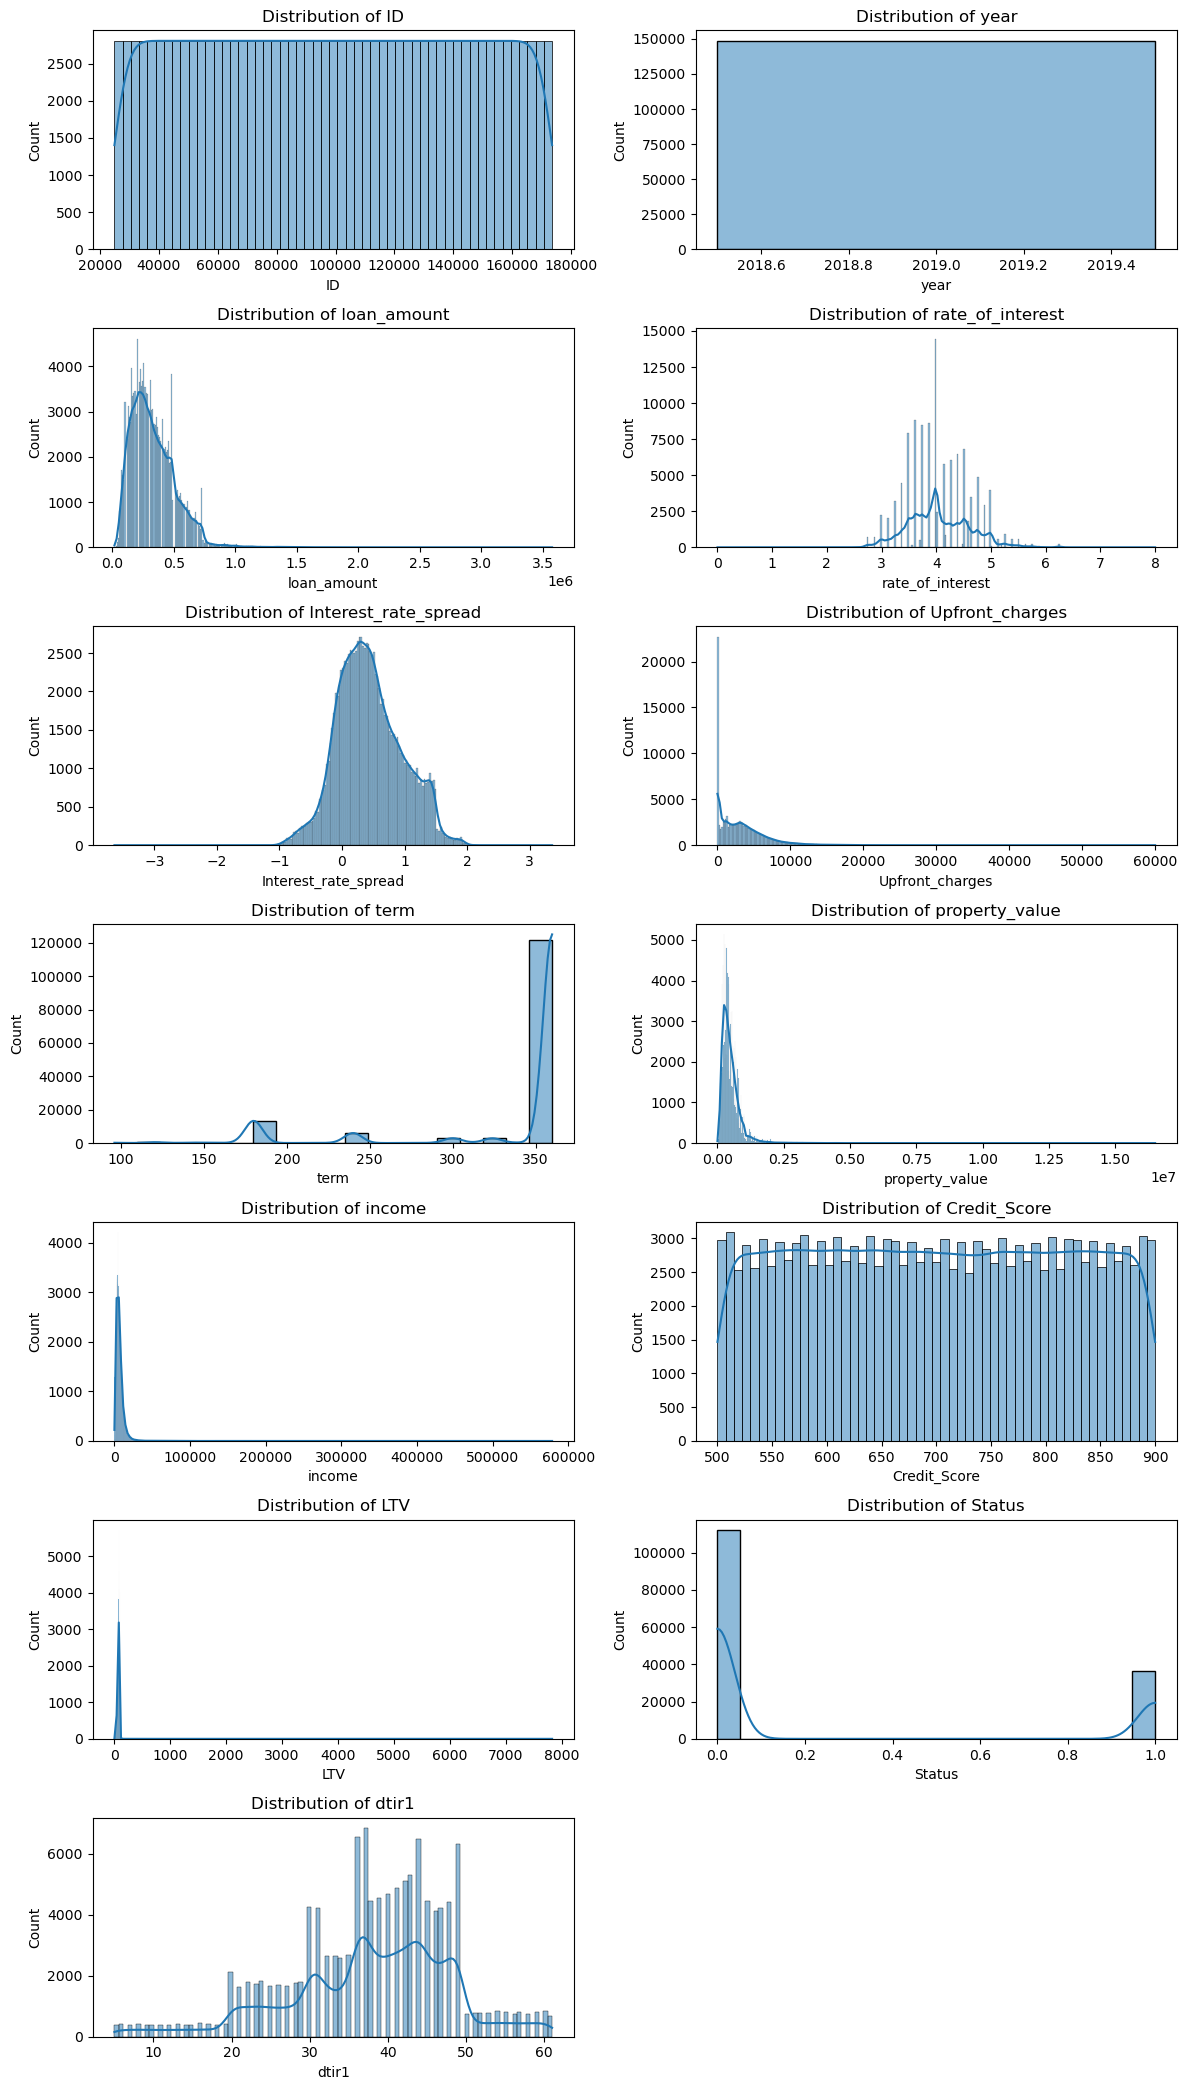

In [ ]:
## Numerical distribution
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
n_cols = 2
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

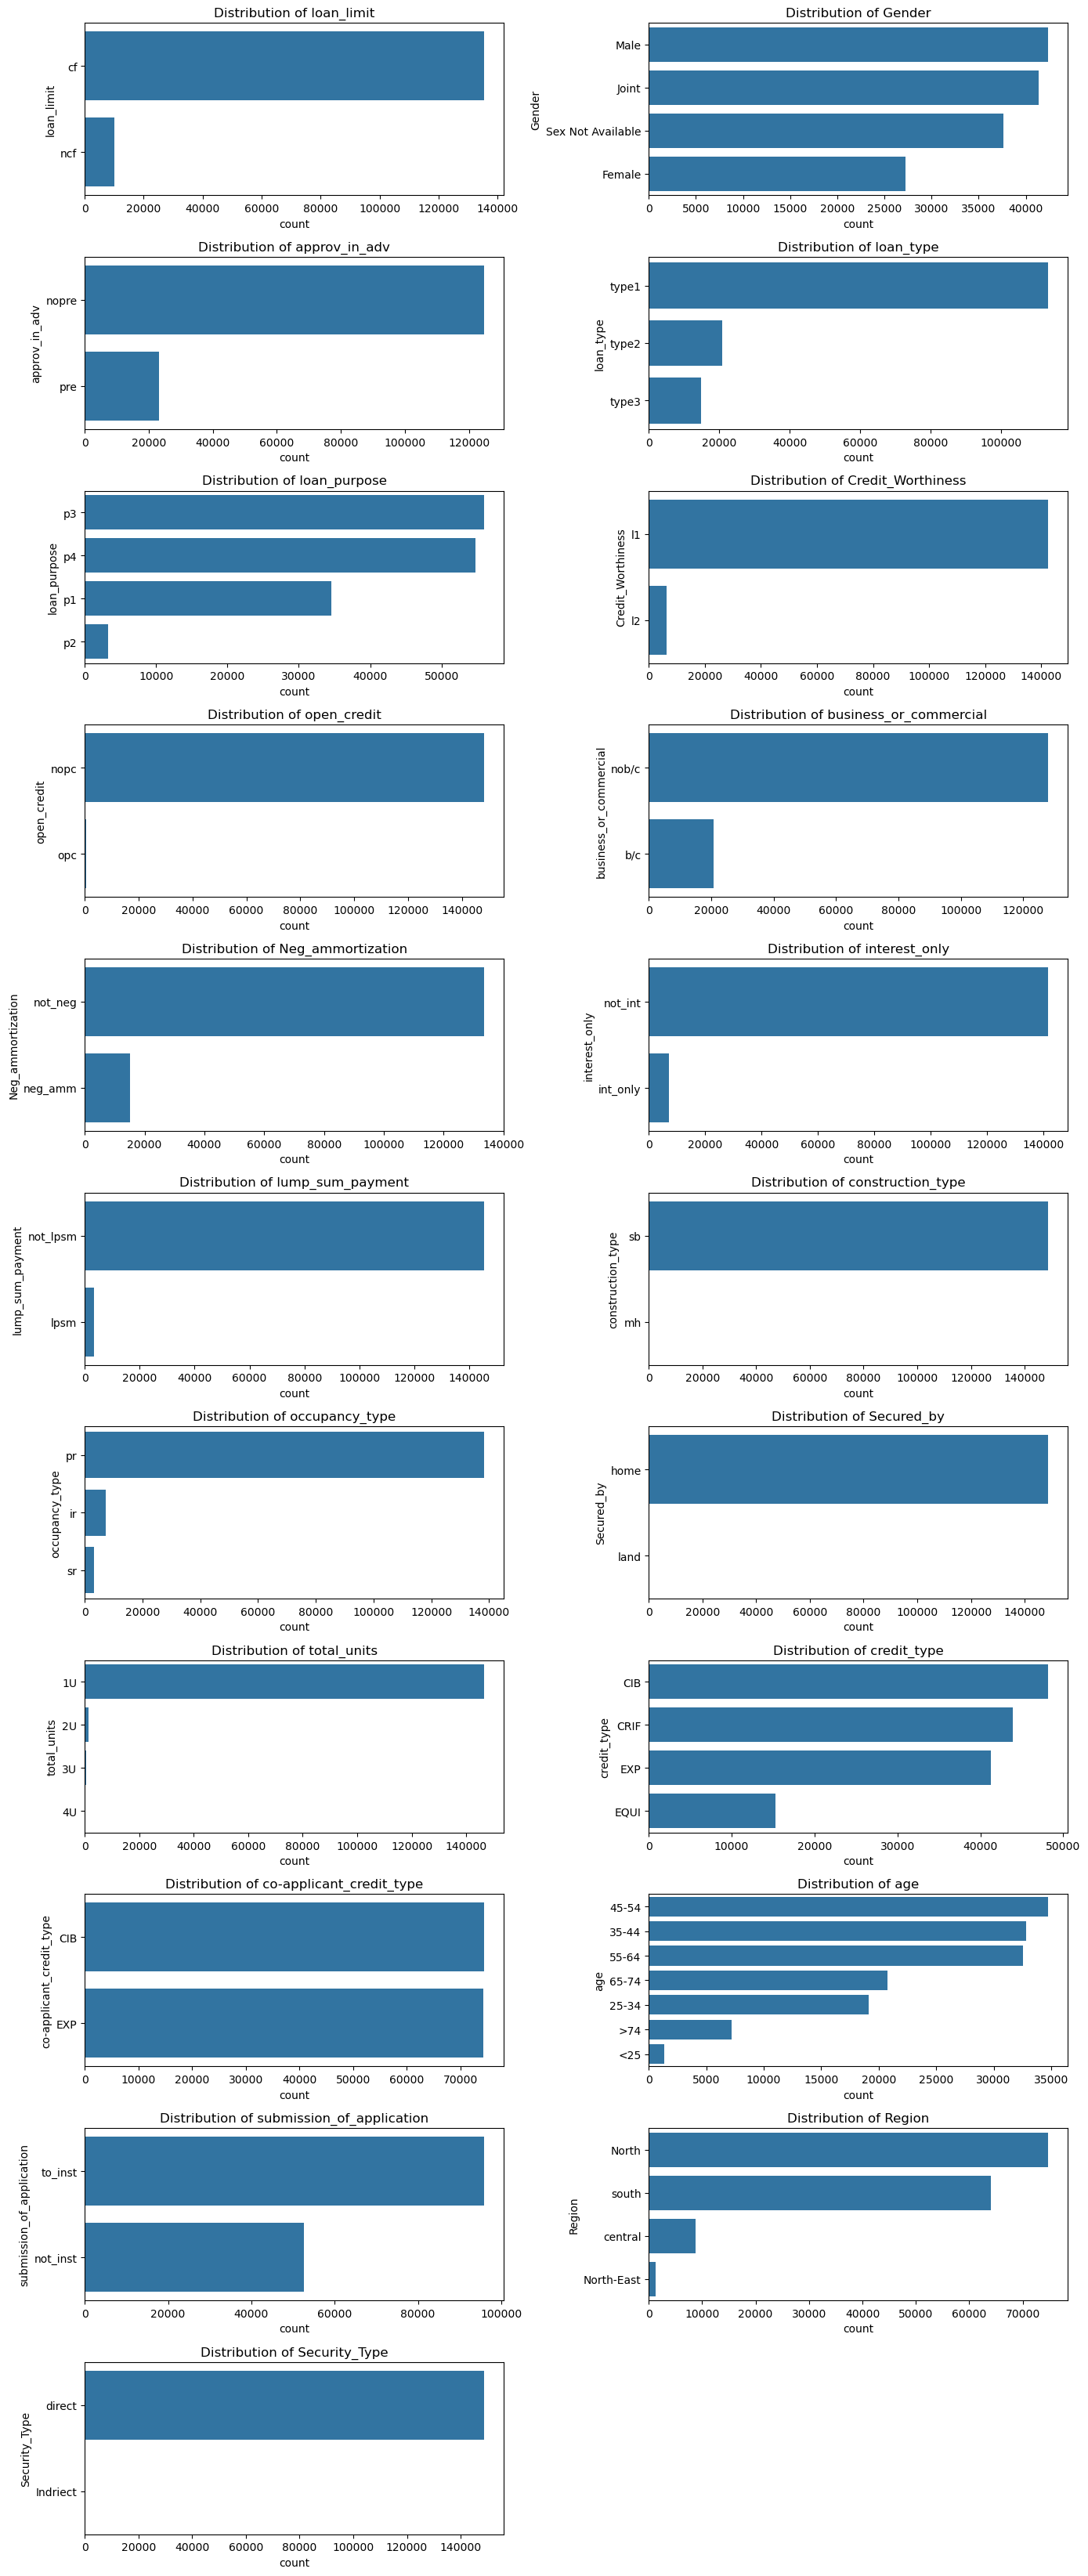

In [ ]:
## Categorical distribution
cat_cols = df.select_dtypes(include=['object']).columns
n_cols = 2
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(y=df[col], order=df[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 2. Data Cleaning

### 2.1 Drop NULL or Substitude
- Choose to substitude because when I use drop NULL, fraud data disappear which make model unlearnable.
- Substitude numerical with median, not mode because NULL is mode, not mean because there are outliner.

In [113]:
df1 = df.copy()

for col in df1.columns:
    if df1[col].dtype == 'object':  # categorical
        df1[col].fillna(df1[col].mode()[0], inplace=True)
    else:  # numerical
        df1[col].fillna(df1[col].median(), inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_21376\498900406.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1[col].fillna(df1[col].median(), inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_21376\498900406.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [114]:
df1.isnull().sum().max()

0

In [115]:
df1.count()

ID                           148670
year                         148670
loan_limit                   148670
Gender                       148670
approv_in_adv                148670
loan_type                    148670
loan_purpose                 148670
Credit_Worthiness            148670
open_credit                  148670
business_or_commercial       148670
loan_amount                  148670
rate_of_interest             148670
Interest_rate_spread         148670
Upfront_charges              148670
term                         148670
Neg_ammortization            148670
interest_only                148670
lump_sum_payment             148670
property_value               148670
construction_type            148670
occupancy_type               148670
Secured_by                   148670
total_units                  148670
income                       148670
credit_type                  148670
Credit_Score                 148670
co-applicant_credit_type     148670
age                         

In [116]:
df1.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,75.135870,North,direct,1,39.0
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


### 2.2 Encoder
- Change categorical to numbers by label encoder.
- Why not one hot encoder? Because this dataset has many categorical which make model bad.

In [ ]:
from sklearn.preprocessing import LabelEncoder

df2 = df1.copy()
cat_cols = df2.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in cat_cols:
    df2[col] = le.fit_transform(df2[col].astype(str))

df2[cat_cols].head(5)

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,Neg_ammortization,interest_only,...,construction_type,occupancy_type,Secured_by,total_units,credit_type,co-applicant_credit_type,age,submission_of_application,Region,Security_Type
0,0,3,0,0,0,0,0,1,1,1,...,1,1,0,0,3,0,0,1,3,1
1,0,2,0,1,0,0,0,0,1,1,...,1,1,0,0,2,1,3,1,0,1
2,0,2,1,0,0,0,0,1,0,1,...,1,1,0,0,3,0,1,1,3,1
3,0,2,0,0,3,0,0,1,1,1,...,1,1,0,0,3,0,2,0,0,1
4,0,1,1,0,0,0,0,1,1,1,...,1,1,0,0,1,1,0,0,0,1


In [118]:
df2['Status'].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

In [119]:
df2['Status'].value_counts(normalize=True) * 100

Status
0    75.355485
1    24.644515
Name: proportion, dtype: float64

In [120]:
df2.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,0,3,0,0,0,0,0,1,...,3,758,0,0,1,98.728814,3,1,1,45.0
1,24891,2019,0,2,0,1,0,0,0,0,...,2,552,1,3,1,75.135870,0,1,1,39.0
2,24892,2019,0,2,1,0,0,0,0,1,...,3,834,0,1,1,80.019685,3,1,0,46.0
3,24893,2019,0,2,0,0,3,0,0,1,...,3,587,0,2,0,69.376900,0,1,0,42.0
4,24894,2019,0,1,1,0,0,0,0,1,...,1,602,1,0,0,91.886544,0,1,0,39.0


In [ ]:
## (ID, year) is just a context which can't be used in modeling
df3 = df2.drop(columns=["ID", "year"])
df3.head()

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,0,3,0,0,0,0,0,1,116500,3.99,...,3,758,0,0,1,98.728814,3,1,1,45.0
1,0,2,0,1,0,0,0,0,206500,3.99,...,2,552,1,3,1,75.135870,0,1,1,39.0
2,0,2,1,0,0,0,0,1,406500,4.56,...,3,834,0,1,1,80.019685,3,1,0,46.0
3,0,2,0,0,3,0,0,1,456500,4.25,...,3,587,0,2,0,69.376900,0,1,0,42.0
4,0,1,1,0,0,0,0,1,696500,4.00,...,1,602,1,0,0,91.886544,0,1,0,39.0


### 2.3 Split data
- Normally use 80/20, but i want to use 70/30 instead because I want to test more than usual due to fraud data.
- I drop ('approv_in_adv', 'Credit_Worthiness') because when I first try modeling it overfit.
- So I choose to drop some feature, but it still ovetfit due to data generate.

In [146]:
leak_cols = ['approv_in_adv', 'Credit_Worthiness']
df4 = df3.drop(columns=leak_cols)

In [161]:
from sklearn.model_selection import train_test_split

X = df4.drop('Status', axis=1).values
y = df4['Status'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=77)

In [160]:
print(df4.columns.tolist())

['loan_limit', 'Gender', 'loan_type', 'loan_purpose', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1']


## 3. Modeling

In [76]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, precision_recall_curve

### 3.1 Logistic Regression
- AUC = 0.758
- AUC = Measure the ability to separate two classes
- 70% is quite good

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

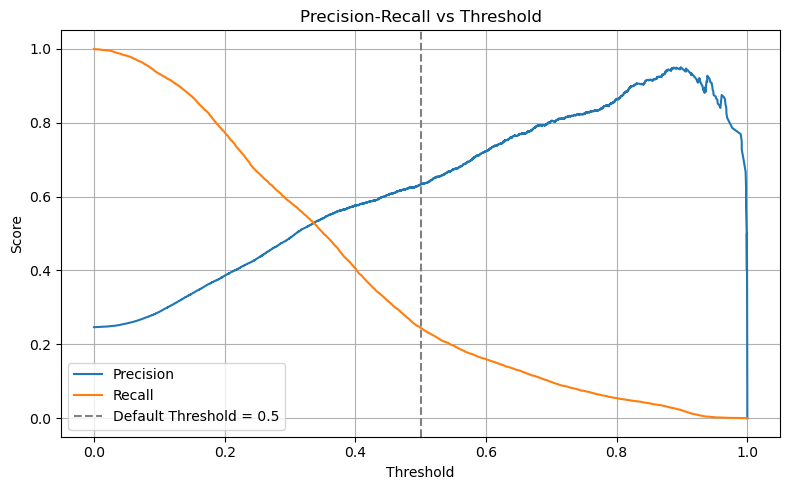


Model: Logistic Regression
Best Params: OrderedDict({'clf__C': 4.486481091627372, 'clf__class_weight': None})
              precision    recall  f1-score   support

           0     0.7941    0.9537    0.8666     33609
           1     0.6328    0.2441    0.3523     10992

    accuracy                         0.7788     44601
   macro avg     0.7135    0.5989    0.6095     44601
weighted avg     0.7544    0.7788    0.7399     44601



In [ ]:
search_spaces = {
    "Logistic Regression": {
        ## clf__C: larger → less penalty, smaller → more penalty. Searches on a log-scale from 1e-3 to 1e2.
        ## clf__class_weight: Automatically weights classes ('balanced') to handle imbalanced or undefined classes (None).
        'clf__C': Real(1e-3, 1e2, prior='log-uniform'),
        'clf__class_weight': Categorical([None, 'balanced'])
    }
}

model_constructors = {
    "Logistic Regression": LogisticRegression(
        ## solver='liblinear': Optimization algorithm that supports penalty='l1'
        ## penalty='l1': Perform L1 regularization → push some coefficients to zero (helps select the spatial variable)
        ## max_iter=1000: Limit the number of iterations to find the optimum to achieve convergence.         
        solver='liblinear',
        penalty='l1',
        max_iter=1000
    )
}

for name, base_model in model_constructors.items():
    pipe = Pipeline([
        ('clf', base_model)
    ])

    search = BayesSearchCV(
        ## estimator=pipe: The model to be trained is the Logistic Regression Pipeline.
        ## search_spaces=...: Try values ​​of C and class_weight within the specified range.
        ## n_iter=20: The number of iterations of the Bayesian search.
        ## scoring='roc_auc': Select the hyperparameter that maximizes the ROC-AUC.
        ## cv=5: Perform a 5-fold cross-validation to assess stability.
        ## Others are general search settings.
        estimator=pipe,
        search_spaces=search_spaces[name],
        n_iter=20,
        scoring='roc_auc',
        cv=5,
        verbose=1, ## “Fitting 5 folds for each of 20 candidates…”
        n_jobs=-1, ## Use every available CPU core → Fastest calculate.
        random_state=77, ## Helps to run repeatedly and get the same result.
        error_score='raise' ## Stop running when encountering an error.
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    y_scores = best_model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, precisions[:-1], label='Precision')
    plt.plot(thresholds, recalls[:-1], label='Recall')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title(f'Precision-Recall vs Threshold')
    plt.axvline(x=0.5, color='gray', linestyle='--', label='Default Threshold = 0.5')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    y_pred = (y_scores >= 0.5).astype(int)
    print(f"\nModel: {name}")
    print("Best Params:", search.best_params_)
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))

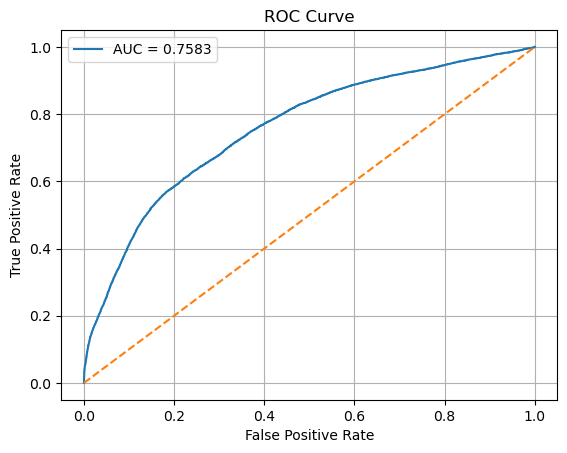

In [181]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, _ = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

### 3.2 XGBoost
- AUC = 100% which mean this is impossible!
- I think this is false, it can't not be in real world.
- This dataset maybe generate, but it's ok to use for learning.

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

c:\Users\User\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:44:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: OrderedDict({'xgb__colsample_bytree': 0.8012579874310085, 'xgb__learning_rate': 0.010549906602305486, 'xgb__max_depth': 8, 'xgb__n_estimators': 83, 'xgb__subsample': 0.8445839912757591})
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     33609
           1     0.9998    0.9990    0.9994     10992

    accuracy                         0.9997     44601
   macro avg     0.9997    0.9995    0.9996     44601
weighted avg     0.9997    0.9997    0.9997     44601



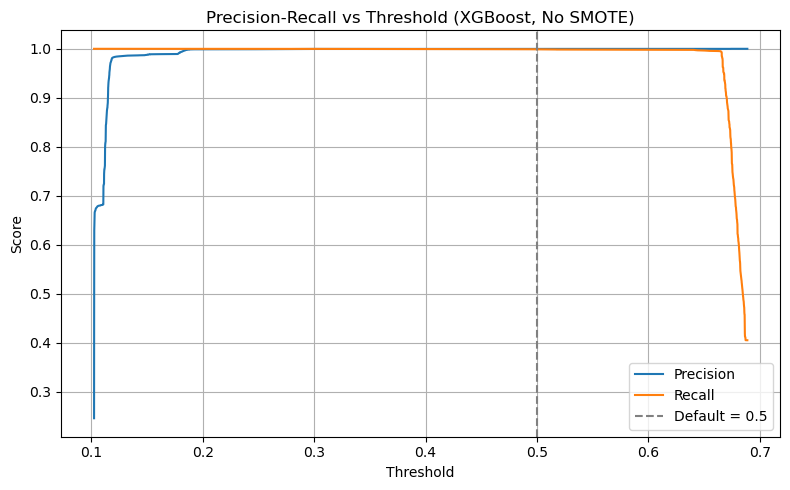

In [ ]:
from xgboost import XGBClassifier

pipeline = Pipeline([
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

search_spaces = {
    ## max_depth controls the depth of the tree (deeper → more likely to overfit, but better at capturing nonlinearities).
    ## Less learning_rate (eta) → more n_estimators are required, but generalization is better.
    ## n_estimators = number of trees.
    ## subsample = random rows (samples) per boosting iteration → reduces overfit.
    ## colsample_bytree = random columns per tree generation → reduces overfit and increases tree diversity.
    'xgb__max_depth': Integer(5, 10),
    'xgb__learning_rate': Real(0.01, 0.1, prior='log-uniform'),
    'xgb__n_estimators': Integer(50, 300),
    'xgb__subsample': Real(0.5, 1.0, prior='uniform'),
    'xgb__colsample_bytree': Real(0.5, 1.0, prior='uniform'),
}

opt = BayesSearchCV(
    estimator=pipeline,
    search_spaces=search_spaces,
    n_iter=30,
    cv=5,
    verbose=1,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=77
)

opt.fit(X_train, y_train)

best_model = opt.best_estimator_
y_scores = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_scores >= 0.5).astype(int)

precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

print("Best Parameters:", opt.best_params_)
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1],   label='Recall')
plt.axvline(x=0.5, linestyle='--', color='gray', label='Default = 0.5')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold (XGBoost, No SMOTE)')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()

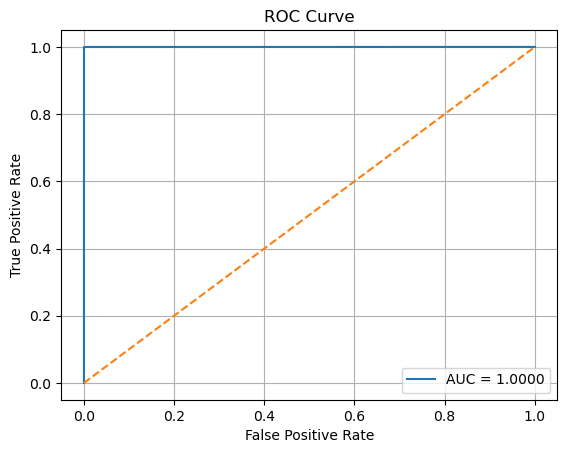

In [183]:
fpr, tpr, _ = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

## 4. Best Model: XGBoost

### 4.1 Importance Feature
- Importance feature = Number of times the feature is used.
- We see that XGBoost use the most on interest_rate_spread.
- And differ from number 2 approximately 16500 unit. 
- Which mean XGBoost can use only interest_rate_spread and still good prediction.
- This emphasize the data is actually generate.

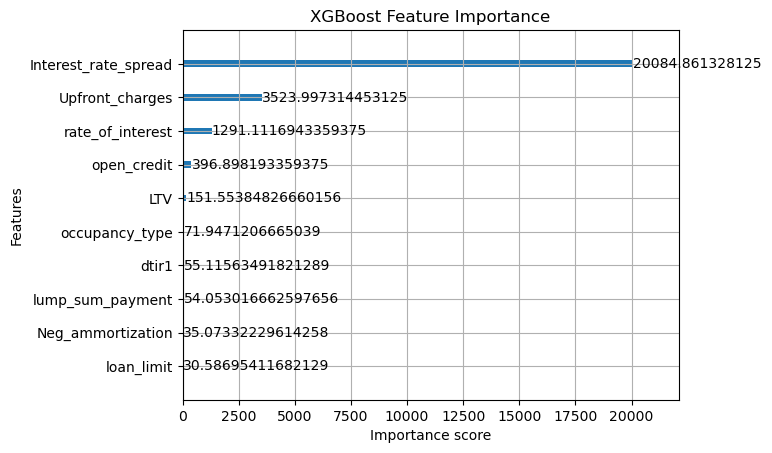

In [184]:
from xgboost import plot_importance
feature_names = df4.drop('Status', axis=1).columns
best_model.named_steps['xgb'].get_booster().feature_names = list(feature_names)
plot_importance(best_model.named_steps['xgb'], importance_type='gain', max_num_features=10)
plt.title("XGBoost Feature Importance")
plt.show()

### 4.2 Confusion Matrix
- Precision (class 1) = 0.9998 → Of the samples the model predicted as "1," only 0.02% were incorrect.
- Recall (class 1) = 0.9990 → The model correctly captured 99.9% of the samples that were "1," with only a few errors.
- True Negative (TN) = 33,607 → Predicted 0 correctly
- False Positive (FP) = 2 → Cases that are actually 0, but the model predicts 1 (very few false alarms)
- False Negative (FN) = 11 → Cases that are actually 1, but the model incorrectly predicts 0
- True Positive (TP) = 10,981 → Predicted 1 correctly
- The model is virtually infallible: it misses only 13 of 44,601 points.

In [185]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     33609
           1     0.9998    0.9990    0.9994     10992

    accuracy                         0.9997     44601
   macro avg     0.9997    0.9995    0.9996     44601
weighted avg     0.9997    0.9997    0.9997     44601



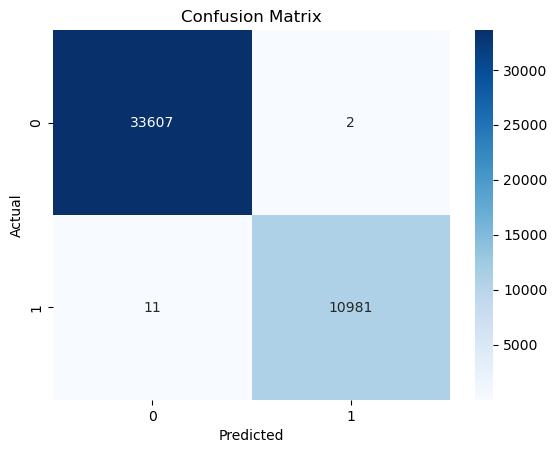

In [186]:
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 5. Conclusion

1. XGBoost produced perfect results on the test set (AUC).
2. Confusion Matrix missed only 13 points.
3. Nearly perfect, confirm the data is generate.
4. Should use more testing data or production data to assess generalizability.
5. For actual use, consider adjusting the threshold to balance FP and FN to suit business objectives.